In [7]:
import os
import json
import time
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import itertools
import subprocess
from tqdm import tqdm


MODELS = {
    "ECOD": {"type": "Probabilistic"}, 
    "COPOD": {"type": "Probabilistic"},
    "PCA": {"type": "Linear"},
    "KPCA": {"type": "Linear"},
    "HBOS": {"type": "Proximity-Based"},
    "CBLOF": {"type": "Proximity-Based"},
    "IForest": {"type": "Outlier Ensembles"},
    "DIF": {"type": "Outlier Ensembles"},
    "R-Graph": {"type": "Graph-based"},
    "LUNAR": {"type": "Graph-based"},
}

TMP_MEMORY_LOG_PATH = "tmp/memory_log.txt"

# DATA_FILEPATH = 'data/a_estabel_sample.csv'
DATA_FILEPATH = 'tmp/a_estabel.csv' # essa é uma pasta temporária, precisa ser criada e o arquivo copiado para lá
DTYPE_FILEPATH = 'data/estabel_dtypes.json'

RESULTS_PATH = "tmp/check_recursos_results.json"

dtypes = json.load(open(DTYPE_FILEPATH))
df = pd.read_csv(DATA_FILEPATH, dtype=dtypes)
total_samples = df.shape[0]

results = [] if not os.path.exists(RESULTS_PATH) else json.load(open(RESULTS_PATH))

experiments = list(itertools.product(MODELS.keys(), [2, 3, 5], [0.001, 0.01, 0.1, 0.5, 1]))
experiments.sort(key=lambda x: (x[0], x[1], x[2]))

for model_name, seed, dataset_ratio in (pbar := tqdm(experiments)):

    if os.path.exists(TMP_MEMORY_LOG_PATH):
        os.remove(TMP_MEMORY_LOG_PATH)

    pbar.set_description(f"Seed: {seed}, Ratio: {dataset_ratio}, Model: {model_name}")

    model_info = MODELS[model_name]
    model_type = model_info["type"]

    # check if this configuration was already run
    if any(r for r in results if r["model"] == model_name and r["dataset_ratio"] == dataset_ratio and r["seed"] == seed):
        # print(f"Skipping already run configuration: model={model_name}, dataset_ratio={dataset_ratio}, seed={seed}")
        continue

    start_time = time.time()

    cmd = f"mprof run --output={TMP_MEMORY_LOG_PATH} check_recursos.py --model={model_name} --dataset_ratio={dataset_ratio} \
                    --seed={seed} --data_filepath={DATA_FILEPATH} --dtype_filepath={DTYPE_FILEPATH} > /dev/null"

    # r = os.system(cmd)
    # print(r)
    try:
        output = subprocess.check_output(cmd, shell=True, stderr=subprocess.STDOUT, timeout=1800)
        output_msg = output.decode()
    except Exception as e:
        output_msg = str(e)
    
    end_time = time.time()
    elapsed_time = end_time - start_time
    
    # get peak memory usage
    with open(TMP_MEMORY_LOG_PATH, 'r') as f:
        lines = f.readlines()
        mem_usages = [float(line.split()[1]) for line in lines if line.startswith('MEM')]
        peak_memory = max(mem_usages) if mem_usages else 0.0

    result = {
        "model": model_name,
        "type": model_type,
        "dataset_ratio": dataset_ratio,
        "num_samples": int(total_samples * dataset_ratio),
        "seed": seed,
        "time_in_seconds": elapsed_time,
        "peak_memory_in_mb": peak_memory,
        "output_msg": output_msg,
    }
    results.append(result)
    # print(f"Result: {result}")

    # save results after each run
    with open(RESULTS_PATH, 'w') as f:
        json.dump(results, f, indent=4)


Seed: 5, Ratio: 1, Model: R-Graph: 100%|██████████| 150/150 [00:00<00:00, 182.33it/s]    


In [8]:
results_df = pd.DataFrame(results)
results_df['peak_memory_in_gb'] = results_df['peak_memory_in_mb'] / 1024
results_df['time_in_minutes'] = results_df['time_in_seconds'] / 60
results_df

,model,type,dataset_ratio,num_samples,seed,time_in_seconds,peak_memory_in_mb,output_msg,peak_memory_in_gb,time_in_minutes
0,CBLOF,Proximity-Based,0.001,500,2,32.169641,4356.410156,,4.254307,0.536161
1,CBLOF,Proximity-Based,0.010,5000,2,32.596501,4048.761719,,3.953869,0.543275
2,CBLOF,Proximity-Based,0.100,50000,2,33.804546,4795.781250,,4.683380,0.563409
3,CBLOF,Proximity-Based,1.000,500000,2,44.069149,11103.140625,,10.842911,0.734486
4,CBLOF,Proximity-Based,0.001,500,3,32.277430,4253.449219,,4.153759,0.537957
...,...,...,...,...,...,...,...,...,...,...
145,R-Graph,Graph-based,0.001,500,5,1233.107631,4727.468750,,4.616669,20.551794
146,R-Graph,Graph-based,0.010,5000,5,1800.125250,4740.156250,Command 'mprof run --output=tmp/memory_log.txt...,4.629059,30.002088
147,R-Graph,Graph-based,0.100,50000,5,1800.118228,4742.808594,Command 'mprof run --output=tmp/memory_log.txt...,4.631649,30.001970
148,R-Graph,Graph-based,0.500,250000,5,1800.120995,5887.796875,Command 'mprof run --output=tmp/memory_log.txt...,5.749802,30.002017


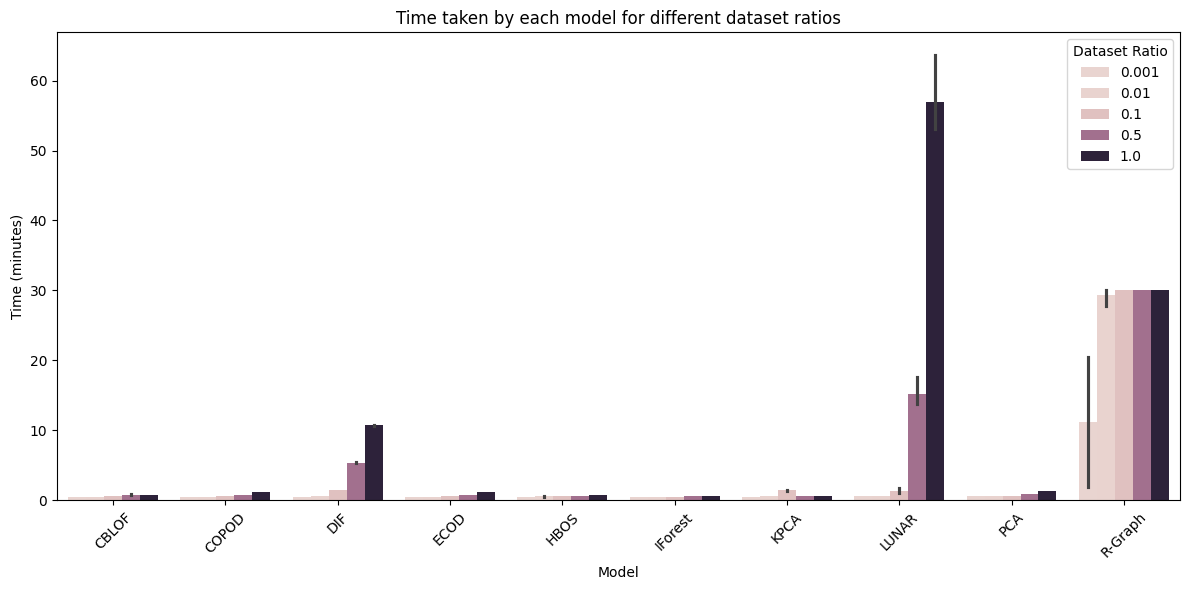

In [9]:
# time bar
plt.figure(figsize=(12, 6))
sns.barplot(data=results_df, x='model', y='time_in_minutes', hue='dataset_ratio')
plt.title('Time taken by each model for different dataset ratios')
plt.ylabel('Time (minutes)')
plt.xlabel('Model')
plt.legend(title='Dataset Ratio')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

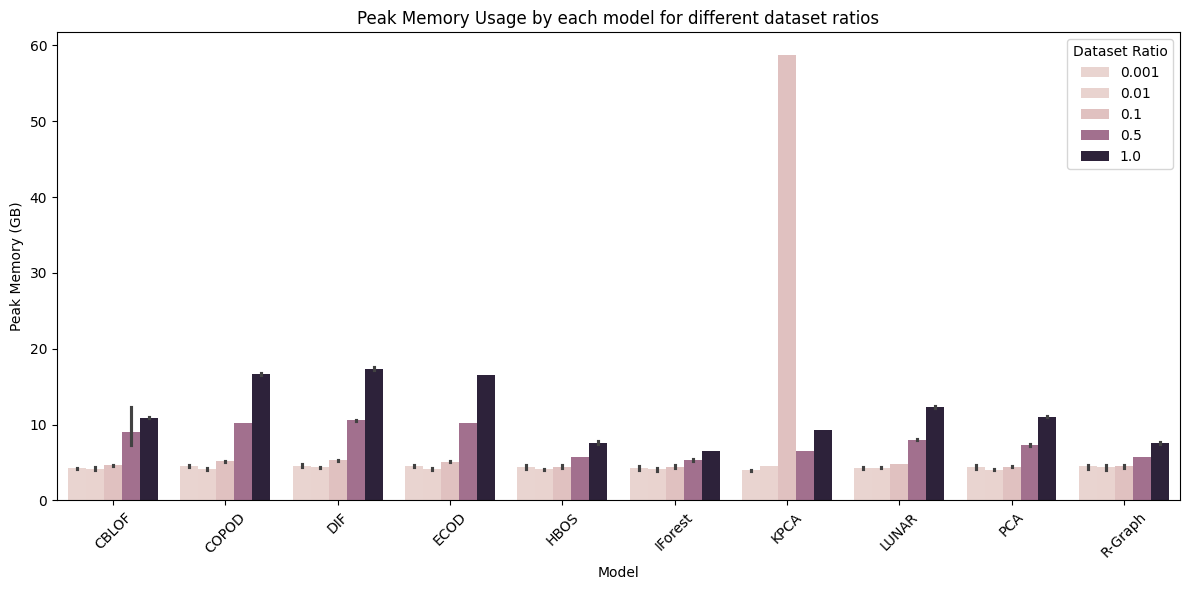

In [10]:
# memory bar
plt.figure(figsize=(12, 6))
sns.barplot(data=results_df, x='model', y='peak_memory_in_gb', hue='dataset_ratio')
plt.title('Peak Memory Usage by each model for different dataset ratios')
plt.ylabel('Peak Memory (GB)')
plt.xlabel('Model')
plt.legend(title='Dataset Ratio')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

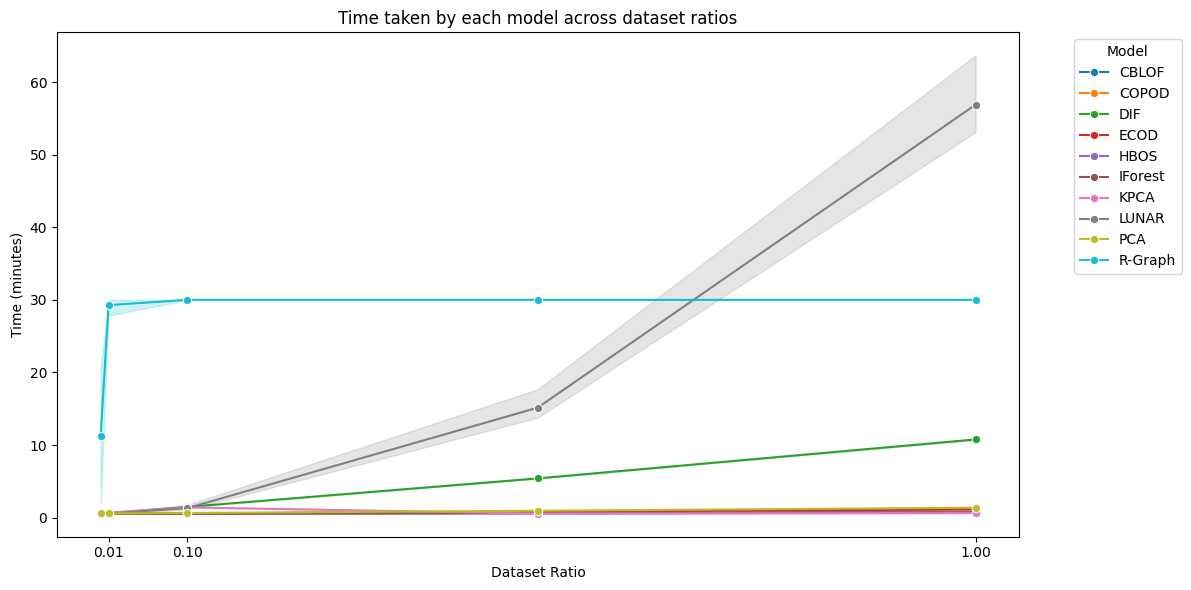

In [11]:

# plot line chart (time)
plt.figure(figsize=(12, 6))
sns.lineplot(data=results_df, x='dataset_ratio', y='time_in_minutes', hue='model', marker='o')
plt.title('Time taken by each model across dataset ratios')
plt.ylabel('Time (minutes)')
plt.xlabel('Dataset Ratio')
plt.legend(title='Model', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks([0.01, 0.1, 1])
plt.tight_layout()
plt.show()


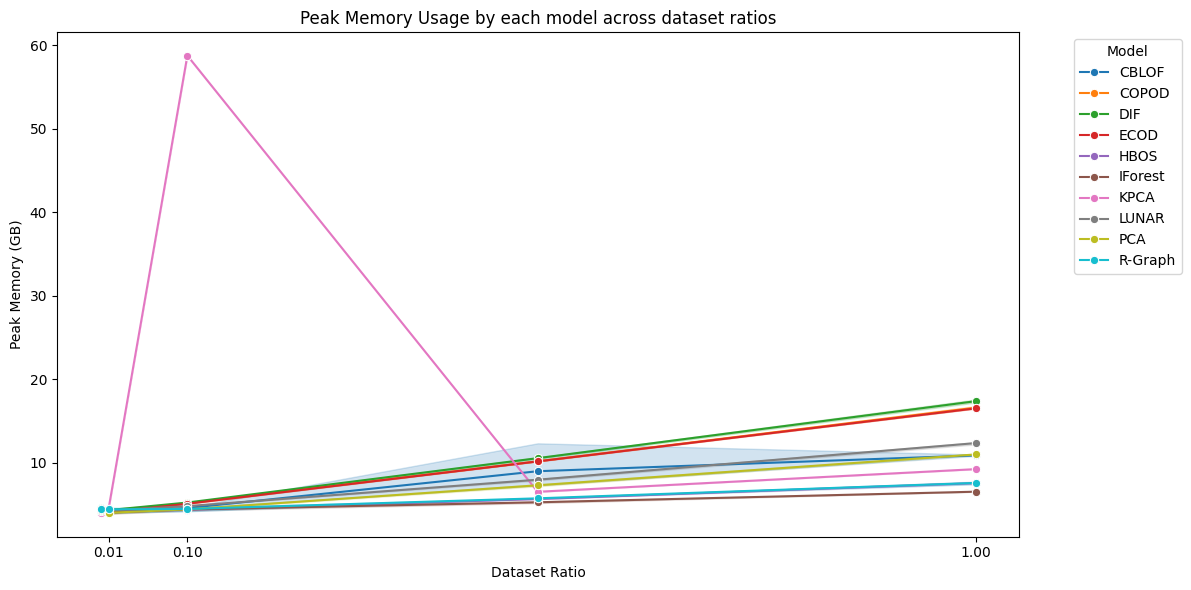

In [12]:

# plot line chart (memory)
plt.figure(figsize=(12, 6))
sns.lineplot(data=results_df, x='dataset_ratio', y='peak_memory_in_gb', hue='model', marker='o')
plt.title('Peak Memory Usage by each model across dataset ratios')
plt.ylabel('Peak Memory (GB)')
plt.xlabel('Dataset Ratio')
plt.legend(title='Model', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks([0.01, 0.1, 1])
plt.tight_layout()
plt.show()